# QCrank Encoding Python Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


In [2]:
def is_power_of_two(n):
    """Return True when n is a positive power of two."""
    return n > 0 and (n & (n - 1)) == 0


def gray_code(value):
    """Return the binary-reflected Gray code of an integer."""
    return value ^ (value >> 1)


def count_trailing_zeros(value):
    """Count consecutive zero bits from the least-significant bit."""
    if value <= 0:
        raise ValueError("value must be a positive integer")
    return (value & -value).bit_length() - 1


def scaled_fwht(values):
    """Apply the scaled fast Walsh-Hadamard transform to a copy of values."""
    transformed = np.asarray(values, dtype=float).copy()
    n = transformed.size

    if not is_power_of_two(n):
        raise ValueError("The transform length must be a positive power of two.")

    step = 1
    while step < n:
        for start in range(0, n, 2 * step):
            for offset in range(step):
                left = start + offset
                right = left + step
                x = transformed[left]
                y = transformed[right]
                transformed[left] = (x + y) / 2.0
                transformed[right] = (x - y) / 2.0
        step *= 2

    return transformed


def gray_permutation(values):
    """Reorder values according to Gray-code indices."""
    values = np.asarray(values)
    return np.array(
        [values[gray_code(i)] for i in range(values.size)],
        dtype=values.dtype,
    )


def audio_to_angles(audio):
    """Map audio amplitudes in [-1, 1] directly to RY angles in [0, pi]."""
    audio = np.asarray(audio, dtype=float)

    if np.any(~np.isfinite(audio)):
        raise ValueError("The audio signal contains NaN or infinite values.")

    if np.any((audio < -1.0) | (audio > 1.0)):
        raise ValueError("Every audio sample must lie in [-1, 1].")

    return (audio + 1.0) * np.pi / 2.0


def angles_to_audio(angles):
    """Map RY angles in [0, pi] back to audio amplitudes in [-1, 1]."""
    angles = np.asarray(angles, dtype=float)
    return 2.0 * angles / np.pi - 1.0


In [3]:
def _control_index(step_index, number_of_address_qubits):
    """Return the address-control index for one Gray-code transition."""
    final_index = (1 << number_of_address_qubits) - 1

    if step_index == final_index:
        return 0

    changed_bit = gray_code(step_index) ^ gray_code(step_index + 1)
    return (
        number_of_address_qubits
        - count_trailing_zeros(changed_bit)
        - 1
    )


def build_qcrank(audio_signal, compression=0.0):
    """
    Build a compressed uniformly controlled RY encoding of a 1D audio signal.

    Parameters
    ----------
    audio_signal : array-like
        One-dimensional samples in [-1, 1]. The length must be a power of two.
    compression : float, default=0
        Percentage of the smallest Walsh-Hadamard coefficients to set to zero.

    Returns
    -------
    QuantumCircuit
        One signal qubit (q0) followed by the address qubits.
    """
    audio_signal = np.asarray(audio_signal, dtype=float)

    if audio_signal.ndim != 1:
        raise ValueError("audio_signal must be one-dimensional.")

    n = audio_signal.size
    if not is_power_of_two(n):
        raise ValueError("The signal length must be a positive power of two.")

    if not 0.0 <= compression <= 100.0:
        raise ValueError("compression must lie between 0 and 100.")

    number_of_address_qubits = n.bit_length() - 1

    target_angles = audio_to_angles(audio_signal)
    coefficients = gray_permutation(scaled_fwht(target_angles))

    number_to_remove = int((compression / 100.0) * n)
    if number_to_remove:
        smallest = np.argsort(np.abs(coefficients))[:number_to_remove]
        coefficients[smallest] = 0.0

    circuit = QuantumCircuit(
        number_of_address_qubits + 1,
        name="QCrank",
    )

    signal_qubit = 0
    address_qubits = range(1, number_of_address_qubits + 1)
    circuit.h(address_qubits)

    i = 0
    while i < n:
        parity = 0

        if not np.isclose(coefficients[i], 0.0):
            circuit.ry(coefficients[i], signal_qubit)

        control = _control_index(i, number_of_address_qubits)
        parity ^= 1 << control
        i += 1

        # Skip zero rotations while retaining the net Gray-code parity.
        while i < n and np.isclose(coefficients[i], 0.0):
            control = _control_index(i, number_of_address_qubits)
            parity ^= 1 << control
            i += 1

        for bit in range(number_of_address_qubits):
            if (parity >> bit) & 1:
                control_qubit = number_of_address_qubits - bit
                circuit.cx(control_qubit, signal_qubit)

    return circuit


def decode_audio(state):
    """Decode amplitudes in [-1, 1] from a QCrank statevector."""
    probabilities = np.asarray(state.probabilities(), dtype=float)

    # q0 is the least-significant qubit, so adjacent probabilities correspond
    # to signal-qubit outcomes 0 and 1 for the same address.
    p0 = np.clip(probabilities[0::2], 0.0, None)
    p1 = np.clip(probabilities[1::2], 0.0, None)

    angles = 2.0 * np.arctan2(np.sqrt(p1), np.sqrt(p0))
    return angles_to_audio(angles)


In [9]:
fs = 8000  # Sampling rate
f = 700  # Frequency of the signal in Hz
N = 16  # Number of samples

t = np.arange(N) / fs  # Time vector for N samples
signal = np.sin(2 * np.pi * f * t)  # Generate the signal

# Print number of samples, total milliseconds, sampling rate and frequency
print(f'Number of samples: {len(signal)}')
print(f'Total duration: {len(signal) / fs * 1000:.2f} ms')
print(f'Sampling rate: {fs} Hz')
print(f'Frequency: {f} Hz')

circuit = build_qcrank(signal, compression=0.0)
state = Statevector.from_instruction(circuit)
decoded_signal = decode_audio(state)

print("Original signal:")
print(np.round(signal, 6))

print("\nDecoded signal:")
print(np.round(decoded_signal, 6))

print("\nMaximum absolute error:")
print(f"{np.max(np.abs(decoded_signal - signal)):.3e}")


Number of samples: 16
Total duration: 2.00 ms
Sampling rate: 8000 Hz
Frequency: 700 Hz
Original signal:
[ 0.        0.522499  0.891007  0.996917  0.809017  0.382683 -0.156434
 -0.649448 -0.951057 -0.97237  -0.707107 -0.233445  0.309017  0.760406
  0.987688  0.92388 ]

Decoded signal:
[ 0.        0.522499  0.891007  0.996917  0.809017  0.382683 -0.156434
 -0.649448 -0.951057 -0.97237  -0.707107 -0.233445  0.309017  0.760406
  0.987688  0.92388 ]

Maximum absolute error:
5.551e-16


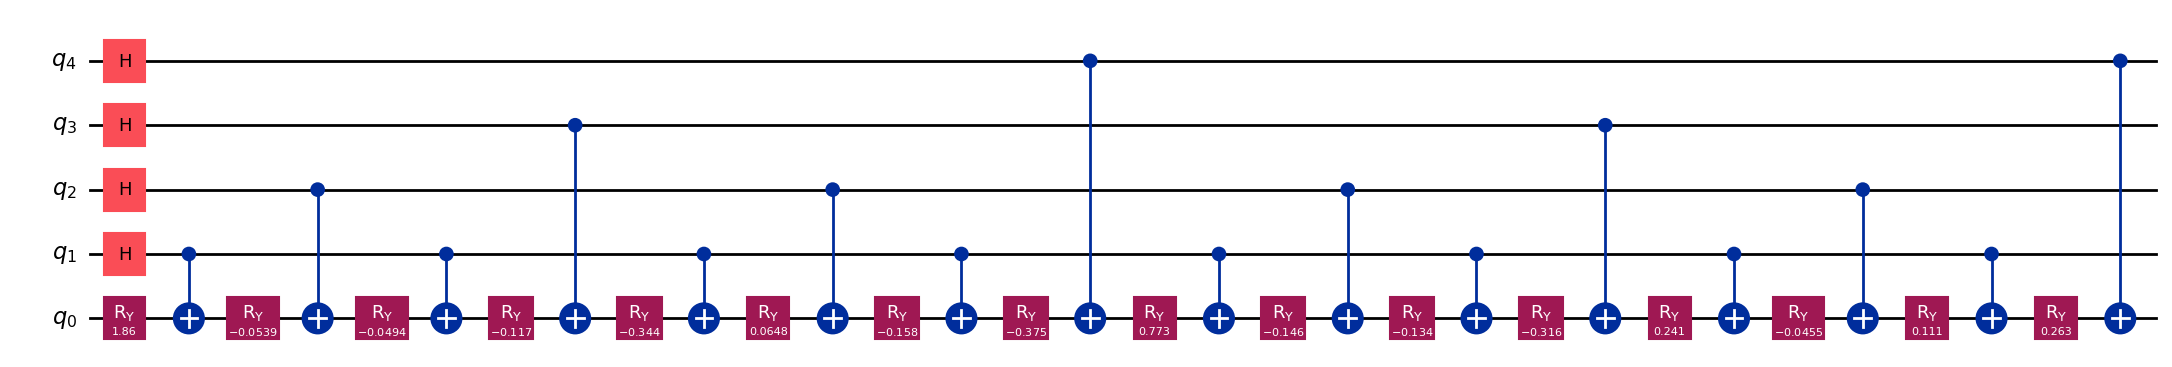

In [10]:
# reverse_bits=True changes only the displayed wire order:
# q0 appears at the bottom, while the circuit itself is unchanged.
display(
    circuit.draw(
        output="mpl",
        fold=-1,
        reverse_bits=True,
    )
)


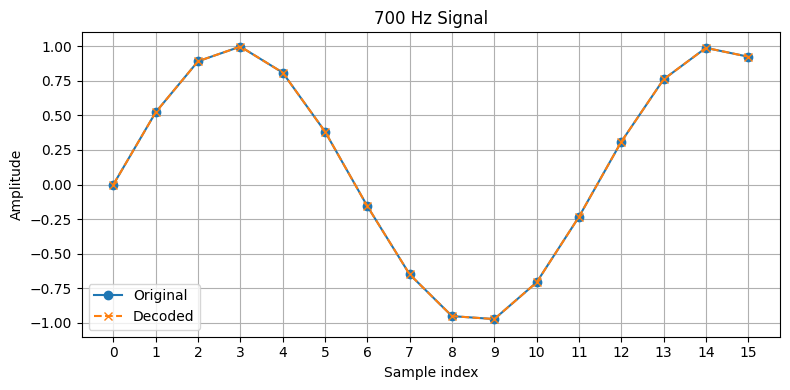

In [11]:
sample_indices = np.arange(signal.size)

plt.figure(figsize=(8, 4))
plt.plot(sample_indices, signal, "o-", label="Original")
plt.plot(sample_indices, decoded_signal, "x--", label="Decoded")

plt.title(f"{f} Hz Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.xticks(sample_indices)
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
